In [1]:
!pip install fastf1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.6 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import fastf1
import pandas as pd
import numpy as np
import os
from google.colab import drive

# 1. Mount Google Drive (Nanti akan muncul pop-up, klik "Allow")
drive.mount('/content/drive')

# 2. Setup Folder Cache di Drive supaya data aman & nggak download ulang terus
drive_cache = '/content/drive/MyDrive/F1_Cache_2026'
if not os.path.exists(drive_cache):
    os.makedirs(drive_cache)
    print(f"Folder cache berhasil dibuat di: {drive_cache}")

fastf1.Cache.enable_cache(drive_cache)

# --- KONFIGURASI DATA ---
year = 2026
test_days = [1, 2, 3, 4, 5, 6]
all_drivers_data = []

print("Sedang menarik data testing Bahrain 2026... Proses ini memakan waktu beberapa menit.")

for day in test_days:
    try:
        # Penentuan Test 1 (Day 1-3) atau Test 2 (Day 4-6)
        test_no = 1 if day <= 3 else 2
        day_no = day if day <= 3 else day - 3

        session = fastf1.get_testing_session(year, test_no, day_no)
        session.load(laps=True, telemetry=False, weather=False) # Load minimalis biar cepet

        laps = session.laps
        if laps.empty:
            continue

        drivers = laps['Driver'].unique()

        for drv in drivers:
            # Ambil lap yang valid dan kompetitif
            drv_laps = laps.pick_driver(drv).pick_quicklaps()

            if not drv_laps.empty:
                times = drv_laps['LapTime'].dt.total_seconds()

                # Data Cleaning: Buang outlier (lap > 110% dari fastest lap driver)
                threshold = times.min() * 1.1
                clean_times = times[times <= threshold]

                all_drivers_data.append({
                    'Driver': drv,
                    'Team': drv_laps['Team'].iloc[0],
                    'FastestLap': times.min(),
                    'LapTimes': clean_times.tolist(),
                    'DayLaps': len(drv_laps)
                })
        print(f"Hari ke-{day} selesai diproses.")

    except Exception as e:
        print(f"Gagal narik data hari ke-{day}: {e}")

# --- AGREGASI & FEATURE ENGINEERING ---
if all_drivers_data:
    df_raw = pd.DataFrame(all_drivers_data)

    # Gabungkan data per driver dari semua hari testing
    final_df = df_raw.groupby(['Driver', 'Team']).agg({
        'FastestLap': 'min',
        'DayLaps': 'sum',
        'LapTimes': 'sum'
    }).reset_index()

    # Hitung statistik utama
    final_df['AvgLapTime'] = final_df['LapTimes'].apply(lambda x: np.mean(x))
    final_df['StdDevLapTime'] = final_df['LapTimes'].apply(lambda x: np.std(x))
    final_df['TotalLaps'] = final_df['DayLaps']

    # Bereskan tabel
    final_df = final_df.drop(columns=['LapTimes', 'DayLaps'])
    final_df = final_df.sort_values(by='FastestLap').reset_index(drop=True)

    print("\n--- DATASET SIAP UNTUK CLUSTERING ---")
    print(final_df)
else:
    print("Wah, data nggak narik sama sekali. Cek koneksi atau status API FastF1.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder cache berhasil dibuat di: /content/drive/MyDrive/F1_Cache_2026
Sedang menarik data testing Bahrain 2026... Proses ini memakan waktu beberapa menit.


core           INFO 	Loading data for Pre-Season Testing - Practice 1 [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Pre-Season Testing - Practice 1 [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for sess

Hari ke-1 selesai diproses.


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for track_status_data. Loading data...
_api  

Hari ke-2 selesai diproses.


...

req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for track_status_data. Loading data...
_api  

Hari ke-5 selesai diproses.


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for track_status_data. Loading data...
_api  

Hari ke-6 selesai diproses.

--- DATASET SIAP UNTUK CLUSTERING ---
   Driver             Team  FastestLap  AvgLapTime  StdDevLapTime  TotalLaps
0     LEC          Ferrari      91.992   97.585406       1.964880        175
1     ANT         Mercedes      92.803   97.574857       1.494118        154
2     PIA          McLaren      92.861   98.499502       1.853060        233
3     NOR          McLaren      92.871   98.217060       1.753752        168
4     VER  Red Bull Racing      93.109   98.066617       1.618276        222
5     RUS         Mercedes      93.197   98.131901       1.694135        242
6     HAM          Ferrari      93.408   98.390497       1.560105        159
7     GAS           Alpine      93.421   99.093140       2.077004        143
8     BEA     Haas F1 Team      93.487   99.695675       1.937273        166
9     BOR             Audi      93.755   99.323235       2.075345        162
10    COL           Alpine      93.818   99.424046       2.271321        175
11    HUL

/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


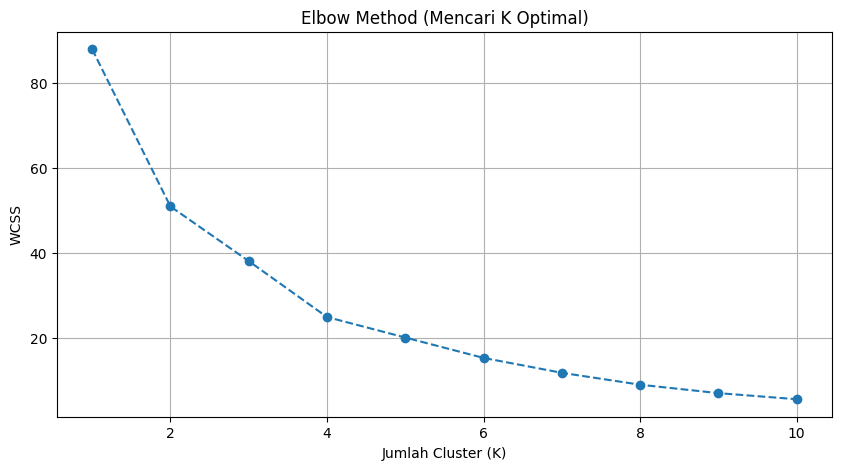

In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pilih fitur yang akan digunakan untuk clustering
features = ['FastestLap', 'AvgLapTime', 'StdDevLapTime', 'TotalLaps']
x = final_df[features]

# 2. Scaling Data (Wajib untuk K-Means)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# 3. Elbow Method untuk menentukan K optimal
wcss = [] # Within-Cluster Sum of Square
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

# Visualisasi Elbow Method
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method (Mencari K Optimal)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [12]:
# 4. Jalankan K-Means
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)

# GUNAKAN fit_predict, bukan fit_transform
final_df['Cluster'] = kmeans.fit_predict(x_scaled)

# --- ATAU PAKAI CARA INI JUGA BISA ---
# kmeans.fit(x_scaled)
# final_df['Cluster'] = kmeans.labels_

print("Clustering berhasil! Kolom 'Cluster' sudah ditambahkan.")


Clustering berhasil! Kolom 'Cluster' sudah ditambahkan.


In [13]:
from sklearn.metrics import silhouette_score

# 1. Hitung Silhouette Score
score = silhouette_score(x_scaled, final_df['Cluster'])
print(f"Silhouette Score: {score:.3f}")

# 2. Cluster Profiling (Mencari karakteristik tiap grup)
profile = final_df.groupby('Cluster').agg({
    'FastestLap': 'mean',
    'AvgLapTime': 'mean',
    'StdDevLapTime': 'mean',
    'TotalLaps': 'mean',
    'Driver': 'count'
}).rename(columns={'Driver': 'Jumlah_Pembalap'}).reset_index()

print("\n--- PROFIL TIAP CLUSTER (Untuk Tabel Jurnal) ---")
print(profile)

# 3. Simpan hasil ke CSV (biar bisa dibuka di Excel buat bikin tabel jurnal)
final_df.to_csv('hasil_clustering_f1_2026.csv', index=False)
print("\nFile 'hasil_clustering_f1_2026.csv' siap didownload!")

Silhouette Score: 0.350

--- PROFIL TIAP CLUSTER (Untuk Tabel Jurnal) ---
   Cluster  FastestLap  AvgLapTime  StdDevLapTime   TotalLaps  Jumlah_Pembalap
0        0   93.948286   99.482752       2.119845  151.142857                7
1        1   96.255000  101.621154       2.172052   70.500000                2
2        2   92.891571   98.066548       1.705475  193.285714                7
3        3   94.588000  100.399734       1.664856  178.666667                6

File 'hasil_clustering_f1_2026.csv' siap didownload!


Kelayakan Model (Silhouette Score): 0.350


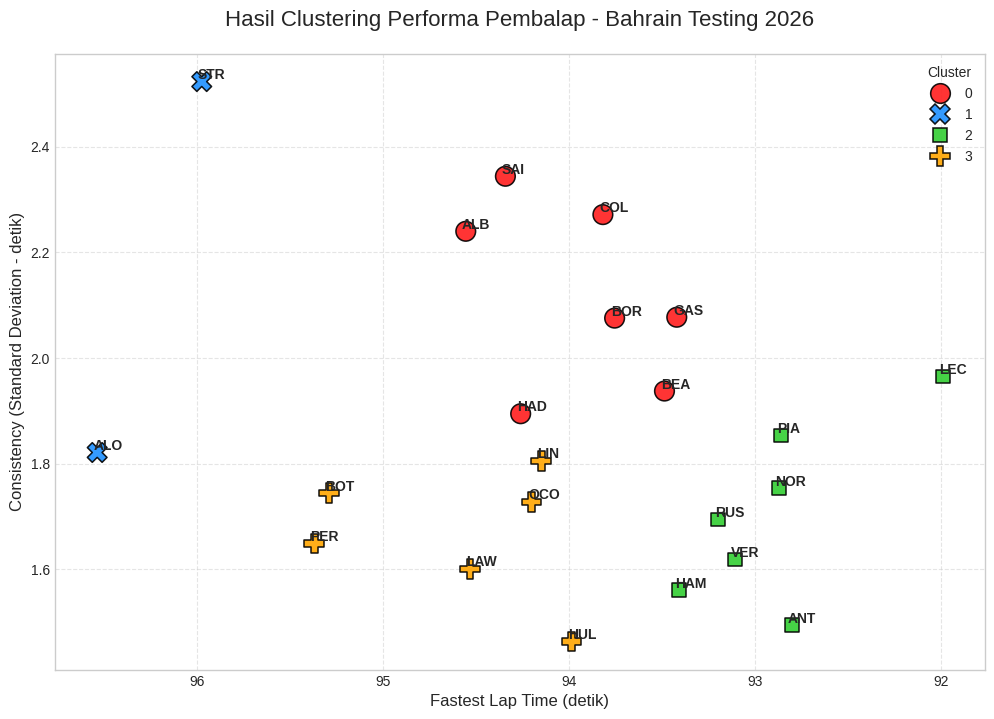


PROSES SELESAI! SILAKAN DOWNLOAD FILE BERIKUT:
1. hasil_clustering_visual.png (Grafik untuk Jurnal)
2. profil_cluster_summary.csv (Ringkasan statistik cluster)
3. dataset_f1_clustered_2026.csv (Data lengkap untuk lampiran)


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score

# --- 1. EVALUASI MODEL (SILHOUETTE SCORE) ---
score = silhouette_score(x_scaled, final_df['Cluster'])
print(f"Kelayakan Model (Silhouette Score): {score:.3f}")

# --- 2. VISUALISASI UTAMA (Scatter Plot) ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 8))

# Plotting
colors = ['#FF1E1E', '#1E90FF', '#32CD32', '#FFA500'] # Warna kontras buat jurnal
scatter = sns.scatterplot(
    data=final_df,
    x='FastestLap',
    y='StdDevLapTime',
    hue='Cluster',
    style='Cluster',
    palette=colors[:k_optimal],
    s=200,
    edgecolor='black',
    alpha=0.9
)

# Label Driver
for i in range(final_df.shape[0]):
    ax.text(final_df.FastestLap[i]+0.02, final_df.StdDevLapTime[i]+0.005,
            final_df.Driver[i], fontsize=10, fontweight='bold')

# Formalitas Grafik
plt.title('Hasil Clustering Performa Pembalap - Bahrain Testing 2026', fontsize=16, pad=20)
plt.xlabel('Fastest Lap Time (detik)', fontsize=12)
plt.ylabel('Consistency (Standard Deviation - detik)', fontsize=12)
plt.gca().invert_xaxis() # Kiri lebih kencang
plt.grid(True, linestyle='--', alpha=0.5)

# Simpan Grafik untuk Jurnal
plt.savefig('hasil_clustering_visual.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 3. TABEL PROFIL CLUSTER (Untuk "Hasil dan Pembahasan") ---
cluster_profile = final_df.groupby('Cluster').agg({
    'FastestLap': 'mean',
    'AvgLapTime': 'mean',
    'StdDevLapTime': 'mean',
    'TotalLaps': 'mean',
    'Driver': 'count'
}).rename(columns={'Driver': 'Jumlah_Pembalap'}).reset_index()

# Simpan tabel profil ke CSV
cluster_profile.to_csv('profil_cluster_summary.csv', index=False)

# --- 4. DATASET AKHIR LENGKAP ---
final_df.to_csv('dataset_f1_clustered_2026.csv', index=False)

print("\n" + "="*40)
print("PROSES SELESAI! SILAKAN DOWNLOAD FILE BERIKUT:")
print("1. hasil_clustering_visual.png (Grafik untuk Jurnal)")
print("2. profil_cluster_summary.csv (Ringkasan statistik cluster)")
print("3. dataset_f1_clustered_2026.csv (Data lengkap untuk lampiran)")
print("="*40)